# LOADING DATASET AND INSPECTING IT


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk import LogicalExpressionException

df = pd.read_csv("IMDB Dataset.csv")

print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
review       str
sentiment    str
dtype: object
review       0
sentiment    0
dtype: int64


# CHECKING CLASS BALANCE

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


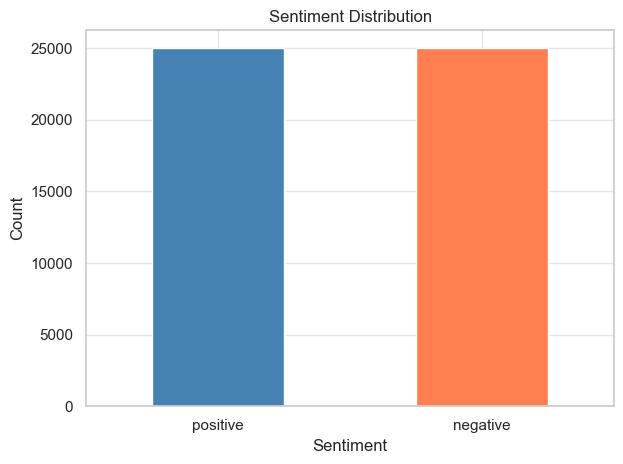

In [2]:
print(df['sentiment'].value_counts())
sns.set_theme(style="whitegrid")
sns.despine()

df['sentiment'].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# REVIEWING LENGTH ANALYSIS

             count        mean          std   min    25%    50%      75%  \
sentiment                                                                  
negative   25000.0  1294.06436   945.892669  32.0  706.0  973.0  1567.25   
positive   25000.0  1324.79768  1031.492627  65.0  691.0  968.0  1614.00   

               max  
sentiment           
negative    8969.0  
positive   13704.0  


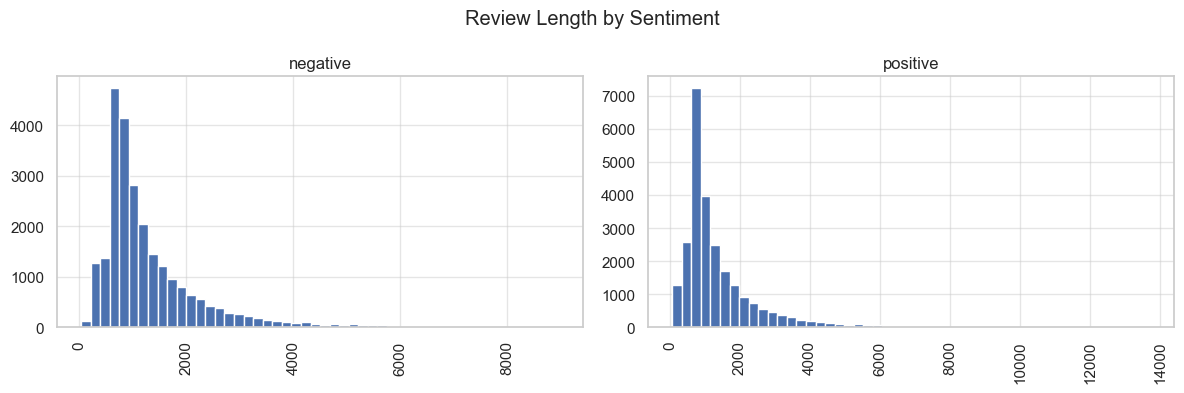

In [3]:
df['review_length'] = df['review'].apply(len)

print(df.groupby('sentiment')['review_length'].describe())

df.hist('review_length', by='sentiment', bins=50, figsize= (12,4))
plt.suptitle('Review Length by Sentiment')
plt.tight_layout()
plt.show()

# DOWNLOADING NLTK RESOURCES

In [4]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acue6\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\acue6\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

# BUILDING TEXT CLEANING FUNCTION

In [5]:
import re
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    # Removing HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # Keeping only letters
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # Lowercase
    text = text.lower()
    # Removing extra spaces
    text = text.strip()
    # Removing stop words
    words = text.split()
    words = [w for w in words if w not in STOPWORDS and len(w) > 2]
    return ' '.join(words)


# Apply to the whole dataset
df['clean_review'] = df['review'].apply(clean_text)


print("ORIGINAL:", df['review'][0][:200])
print("\nCleaned:", df['clean_review'][0][:200])


ORIGINAL: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

Cleaned: one reviewers mentioned watching episode hooked right exactly happened first thing struck brutality unflinching scenes violence set right word trust show faint hearted timid show pulls punches regards


# ENCDOING LABELS AND SPLITTING DATA

In [6]:
from sklearn.model_selection import train_test_split

# Converting labels to numbers
df['label'] = (df['sentiment'] == 'positive').astype(int)
# Positive = 1, Negative = 0

X = df['clean_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")


Train set size: 40000
Test set size: 10000


# USING TF-IDF Vectorization

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5,
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Feature matrix shape: {X_train_tfidf.shape}")


Feature matrix shape: (40000, 10000)


# TRAIN LOGISTIC REGRESSION

In [8]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    C = 1.0,
    random_state = 42
)
lr_model.fit(X_train_tfidf, y_train)
print("Logistic Regression Trained!")


Logistic Regression Trained!


# TRAINING NAIVE BAYES

In [9]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)
print("Naive Bayes Trained!")



Naive Bayes Trained!


# SAVING THE BEST MODEL WITH PICKLE

In [10]:
import pickle
import os

os.makedirs('model', exist_ok=True)

# SAVING MODEL
with open("model/model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

# SAVING VECTORIZER
with open('model/vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("Model And Vectorizer Saved!")


Model And Vectorizer Saved!


# COMPARING MODEL ACCURACY

In [11]:
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': lr_model,
    'Naive Bayes': nb_model,
}

for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name:25} Accuracy: {acc:4f}%")


Logistic Regression       Accuracy: 0.896800%
Naive Bayes               Accuracy: 0.867000%


# THE FULL CLASSIFICATION REPORT

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_lr = lr_model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_lr,
      target_names = ["Negative", "Positive"]))



              precision    recall  f1-score   support

    Negative       0.90      0.89      0.90      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



# PLOTTING CONFUSION MATRIX

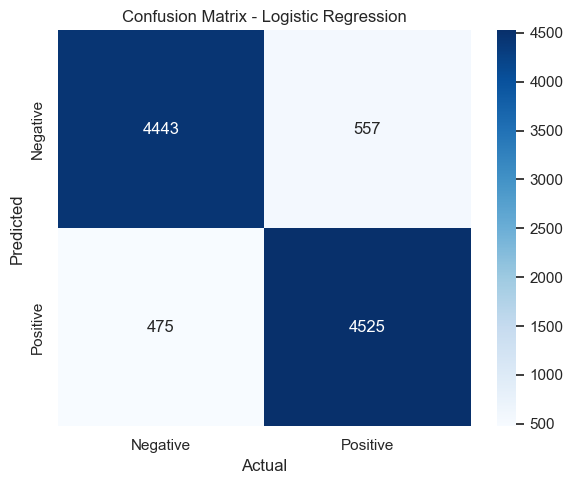

In [13]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize = (6, 5))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues",
            xticklabels = ["Negative", "Positive"],
            yticklabels = ["Negative", "Positive"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi = 150)
plt.show()



# THE TOP WORDS

In [14]:
feature_names = vectorizer.get_feature_names_out()
coefs = lr_model.coef_[0]

top_positive = sorted(zip(coefs, feature_names), reverse = True)[:15]
top_negative = sorted(zip(coefs, feature_names))[:15]

print("TOP POSITIVE WORDS:")
for coef, word in top_positive:
    print(f" {word:20} {coef:.3f}")


TOP POSITIVE WORDS:
 great                7.139
 excellent            6.571
 perfect              5.424
 amazing              4.910
 wonderful            4.779
 best                 4.615
 hilarious            4.371
 loved                4.303
 one best             4.204
 brilliant            4.144
 fun                  4.129
 favorite             3.983
 enjoyed              3.947
 today                3.905
 superb               3.853
